## Modelos para predicción de puntaje


## **Ingenieria de caracteristicas:**

In [ ]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

# Drive
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# Ruta al CSV en Drive
df= pd.read_csv("/content/drive/MyDrive/Proyecto_Tecnicas_ML/df_cleaned_02.csv")
display(df.head(5))

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,2018,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,161.0,174.0,139.0,161.0,128.0
1,2018,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,Si,Estrato 2,Si,Si,No sabe,142.0,77.0,124.0,130.0,153.0
2,2018,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,128.0,165.0,169.0,159.0,124.0
3,2018,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,108.0,157.0,148.0,115.0,142.0
4,2018,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,NaN,NaN,NaN,NaN,NaN,132.0,116.0,101.0,123.0,107.0


In [ ]:
# Get the number of rows and columns
num_rows, num_cols = df.shape

# Display the number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 451782
Number of columns: 25


##Se crea la varible puntaje global (0-300):

se calcula sumando los puntajes indivuales y dividiendo en 5, como indica la cartilla de informacion del icfes saber pro: https://www.icfes.gov.co/wp-content/uploads/2025/03/00_entender_resultados_Saber_PRO.pdf


In [ ]:
# Define the score columns
score_columns_individual = [
    'MOD_LECTURA_CRITICA_PUNT',
    'MOD_RAZONA_CUANTITAT_PUNT',
    'MOD_COMPETEN_CIUDADA_PUNT',
    'MOD_COMUNI_ESCRITA_PUNT',
    'MOD_INGLES_PUNT'
]

# Calculate the sum of individual scores
df['sum_individual_scores'] = df[score_columns_individual].sum(axis=1)

# Calculate the average score (puntaje global 3)
df['puntaje global'] = df['sum_individual_scores'] / 5

# Drop the intermediate sum column
df = df.drop(columns=['sum_individual_scores','MOD_RAZONA_CUANTITAT_PUNT','MOD_COMUNI_ESCRITA_PUNT', 'MOD_LECTURA_CRITICA_PUNT','MOD_INGLES_PUNT','MOD_COMPETEN_CIUDADA_PUNT'])

# Display the first few rows with the new 'puntaje global 3' column
display(df.head())

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global
0,2018,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,No,Primaria completa,Si,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,152.6
1,2018,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,No,Si,No Aplica,No,Si,Estrato 2,Si,Si,No sabe,125.2
2,2018,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Si,Educación profesional incompleta,Si,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,149.0
3,2018,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,No,Si,Técnica o tecnológica completa,Si,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,134.0
4,2018,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,No,Si,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8


In [ ]:
# Calculate the maximum and minimum values of 'puntaje global2'
max_puntaje_global2 = df['puntaje global'].max()
min_puntaje_global2 = df['puntaje global'].min()

# Display the maximum and minimum values
print(f"Maximum 'puntaje global': {max_puntaje_global2}")
print(f"Minimum 'puntaje global': {min_puntaje_global2}")

Maximum 'puntaje global': 278.2
Minimum 'puntaje global': 0.0


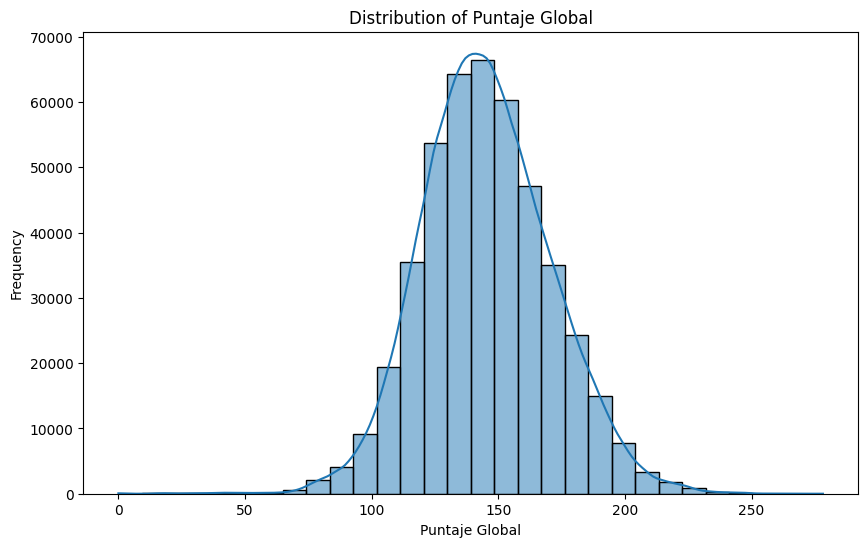

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['puntaje global'], kde=True, bins=30)
plt.title('Distribution of Puntaje Global')
plt.xlabel('Puntaje Global')
plt.ylabel('Frequency')
plt.show()

se toma el valor mas grande del intervalo y se pasa a numero, es mejor sobreestimar el valor de la matricula, ya que incrementa anualmente, tambien se tranforma el numero de horas trabajadas Nan a 0, el valor maximo del los intervalos (porque no trabaja de esas horas) o el minimo en el caso donde solo habia esa informacion (ej:Más de 30 horas) porque es un numero de hora que si o si trabaja.

Se tranforma EN ESTU_METODO_PRGM en dos categorias presencial y a distancia, (se borra distancia vitual, y virtual porque son lo mismo)
SE borran el nombre de la universidad, el perioodo y el caracter academico.

se trasforma la varible FAMI_ESTRATOVIVIENDA a numerico y los  sin estrato se tranforman a cero que son consideradas personas sin hogar.

In [ ]:
#TRANSFORMACIÓN ESTU_HORASSEMANATRABAJA
def extract_numeric_hours(value):
    """
    Extracts a numerical representation from the ESTU_HORASSEMANATRABAJA string.
    Returns the upper bound of the range, the specified value for 'Más de' and 'Menos de',
    and 0 for NaN values.
    """
    if pd.isna(value):
        return 0
    value = value.lower()
    if 'menos de' in value:
        return 10.0
    elif 'más de' in value:
        return 30.0
    elif 'y' in value and 'horas' in value:
        try:
            parts = value.split('y')
            if len(parts) > 1:
                return float(parts[1].split()[0])
            else:
                return np.nan # Should not happen based on the categories, but as a fallback
        except (ValueError, IndexError):
            return np.nan # Handle potential errors during conversion
    elif value.isdigit(): # Handle cases that are already just numbers
        return float(value)
    else:
        return np.nan # Handle any other unexpected formats

# Apply the function to the column
df['ESTU_HORASSEMANATRABAJA'] = df['ESTU_HORASSEMANATRABAJA'].apply(extract_numeric_hours)

#TRANSFORMACIÓN ESTU_VALORMATRICULAUNIVERSIDAD
def extract_numeric_matricula(value):
    """
    Extracts a numerical representation from the ESTU_VALORMATRICULAUNIVERSIDAD string.
    Returns the upper bound of the range or the lower bound for "Más de".
    """
    if pd.isna(value):
        return np.nan
    value = value.lower()
    if 'menos de' in value:
        # Extract the upper bound
        return float(value.split('menos de')[1].split()[0])
    elif 'más de' in value:
        # Extract the lower bound
        return float(value.split('más de')[1].split()[0])
    elif 'y' in value and 'millones' in value:
        # Handle ranges like "Entre X y Y millones", take the upper bound
        parts = value.split('y')
        if len(parts) > 1:
            try:
                return float(parts[1].split()[0])
            except (ValueError, IndexError):
                return np.nan
        else:
            return np.nan
    else:
        # Handle any other cases, return NaN or a default value if needed
        return np.nan

# Apply the function to the column
df['ESTU_VALORMATRICULAUNIVERSIDAD'] = df['ESTU_VALORMATRICULAUNIVERSIDAD'].apply(extract_numeric_matricula)

#TRANSFORMACIÓN FAMI_ESTRATOVIVIENDA
def transform_estrato_to_numeric(value):
    """
    Transforms the 'FAMI_ESTRATOVIVIENDA' values to a numerical representation.
    'Estrato X' becomes X, and 'Sin Estrato' becomes 0. NaN values are kept as NaN.
    """
    if pd.isna(value):
        return np.nan # Keep NaN as NaN
    elif value == 'Sin Estrato':
        return 0
    elif 'Estrato' in value:
        try:
            # Extract the number after 'Estrato '
            return int(value.split(' ')[1])
        except (ValueError, IndexError):
            # Handle cases where the format might be unexpected
            return np.nan # Or return 0, depending on how you want to handle errors
    else:
        # Handle any other unexpected values
        return np.nan # Or return 0

# Apply the function to the 'FAMI_ESTRATOVIVIENDA' column
df['FAMI_ESTRATOVIVIENDA'] = df['FAMI_ESTRATOVIVIENDA'].apply(transform_estrato_to_numeric)


# CONSOLIDAR CATEGORÍAS EN ESTU_METODO_PRGM
df['ESTU_METODO_PRGM'] = df['ESTU_METODO_PRGM'].replace(['DISTANCIA VITUAL', 'VIRTUAL'], 'DISTANCIA')


# ELIMINACIÓN DE VARIABLES
df = df.drop(columns=['INST_NOMBRE_INSTITUCION', 'INST_CARACTER_ACADEMICO','PERIODO','ESTU_VALORMATRICULAUNIVERSIDAD' ])

# Display the first few rows to verify the columns have been removed
display(df.head())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global
0,ADMINISTRACIÓN,PRESENCIAL,No,No,20.0,N,F,Si,No,Primaria completa,Si,Si,2.0,Si,Si,Secundaria (Bachillerato) incompleta,152.6
1,CONTADURÍA PUBLICA,DISTANCIA,No,No,30.0,N,M,No,Si,No Aplica,No,Si,2.0,Si,Si,No sabe,125.2
2,ADMINISTRACIÓN,PRESENCIAL,No,Si,0.0,N,F,Si,Si,Educación profesional incompleta,Si,Si,4.0,Si,Si,Técnica o tecnológica incompleta,149.0
3,PSICOLOGÍA,DISTANCIA,No,No,10.0,N,M,No,Si,Técnica o tecnológica completa,Si,Si,3.0,Si,Si,Técnica o tecnológica completa,134.0
4,ADMINISTRACIÓN,DISTANCIA,No,No,0.0,N,M,No,Si,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8



se fusionan las columnas ESTU_PAGOMATRICULABECA, ESTU_PAGOMATRICULACREDITO , ESTU_PAGOMATRICULAPADRES, ESTU_PAGOMATRICULAPROPIO en una sola variable categorica que sea PAGO_MATRICULA: donde ESTU_PAGOMATRICULABECA es si enconces pone BECA, o ESTU_PAGOMATRICULACREDITO es entonces pone CREDITO, ESTU_PAGOMATRICULAPADRES es si pone PADRES, o ESTU_PAGOMATRICULAPROPIO es si pone PROPIO

Si ninguna de las columnas de pago originales es 'Si', asignaremos una categoría por defecto, por ejemplo, 'NINGUNO'.

In [ ]:
def create_pago_matricula_category(row):
    """
    Creates the 'PAGO_MATRICULA' category based on the values in the payment columns.
    Prioritizes BECA, then CREDITO, then PADRES, then PROPIO.
    """
    if row['ESTU_PAGOMATRICULABECA'] == 'Si':
        return 'BECA'
    elif row['ESTU_PAGOMATRICULACREDITO'] == 'Si':
        return 'CREDITO'
    elif row['ESTU_PAGOMATRICULAPADRES'] == 'Si':
        return 'PADRES'
    elif row['ESTU_PAGOMATRICULAPROPIO'] == 'Si':
        return 'PROPIO'
    else:
        return 'NINGUNO' # Or another appropriate default category

# Apply the function to create the new 'PAGO_MATRICULA' column
df['PAGO_MATRICULA'] = df.apply(create_pago_matricula_category, axis=1)

# Drop the original payment columns
df = df.drop(columns=['ESTU_PAGOMATRICULABECA', 'ESTU_PAGOMATRICULACREDITO', 'ESTU_PAGOMATRICULAPADRES', 'ESTU_PAGOMATRICULAPROPIO'])

# Display the first few rows with the new column and without the old ones
display(df.head())

# Display the unique values in the new column
print("\nUnique values in 'PAGO_MATRICULA':")
print(df['PAGO_MATRICULA'].unique())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria completa,Si,Si,2.0,Si,Si,Secundaria (Bachillerato) incompleta,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,No Aplica,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Educación profesional incompleta,Si,Si,4.0,Si,Si,Técnica o tecnológica incompleta,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica o tecnológica completa,Si,Si,3.0,Si,Si,Técnica o tecnológica completa,134.0,PROPIO
4,ADMINISTRACIÓN,DISTANCIA,0.0,N,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8,PROPIO



Unique values in 'PAGO_MATRICULA':
['PADRES' 'PROPIO' 'CREDITO' 'BECA' 'NINGUNO']


SE TRANFORMA  FAMI_EDUCACIONMADRE A siete valores: ninguno, primaria, bachillerato, tecnico, profesional, postgrado, no sabe.  aquellos que originalmente aparecen incompleto (ej: secundaria incompleta ) se reemplazan por el ultimo nivel de educacion completado (obtuvieron el titulo)  excepto primaria.  lo mismo con padre


(tranforma los valores de FAMI_EDUCACIONMADRE por: Secundaria (Bachillerato) incompleta a Primaria, Técnica o tecnológica incompleta a Bachillerato, Técnica o tecnológica completa a Técnica, Primaria completa a Primaria, Primaria incompleta a Primaria, Postgrado a Postgrado, Secundaria (Bachillerato) completa a Bachillerato, Educación profesional incompleta a Bachillerato, Educación profesional completa a profesional, No Aplica a Ninguno, Ninguno a Ninguno.)


(tranforma los valores de FAMI_EDUCACIONPADRE por: Primaria completa por Primaria, No Aplica a Ninguno, Educación profesional incompleta a Bachillerato, Técnica o tecnológica completa a Técnica,Postgrado a Postgrado, Secundaria (Bachillerato) incompleta a Primaria, Primaria incompleta a Primaria, Técnica o tecnológica incompleta a Bachillerato, Ninguno a Ninguno, Educación profesional completa a profesional, Secundaria (Bachillerato) completa a Bachillerato, nan a No sabe)

In [ ]:
# Display unique values for FAMI_EDUCACIONMADRE
print("Unique values in 'FAMI_EDUCACIONMADRE':")
print(df['FAMI_EDUCACIONMADRE'].unique())

# Display unique values for FAMI_EDUCACIONPADRE
print("\nUnique values in 'FAMI_EDUCACIONPADRE':")
print(df['FAMI_EDUCACIONPADRE'].unique())

Unique values in 'FAMI_EDUCACIONMADRE':
['Secundaria (Bachillerato) incompleta' 'No sabe'
 'Técnica o tecnológica incompleta' 'Técnica o tecnológica completa' nan
 'Primaria completa' 'Primaria incompleta' 'Postgrado'
 'Secundaria (Bachillerato) completa' 'Ninguno'
 'Educación profesional incompleta' 'Educación profesional completa'
 'No Aplica']

Unique values in 'FAMI_EDUCACIONPADRE':
['Primaria completa' 'No Aplica' 'Educación profesional incompleta'
 'Técnica o tecnológica completa' nan 'Postgrado'
 'Secundaria (Bachillerato) incompleta' 'Primaria incompleta'
 'Técnica o tecnológica incompleta' 'Ninguno'
 'Educación profesional completa' 'Secundaria (Bachillerato) completa'
 'No sabe']


In [ ]:
# Define the mapping for FAMI_EDUCACIONMADRE
education_mapping_madre = {
    'Secundaria (Bachillerato) incompleta': 'Primaria',
    'Técnica o tecnológica incompleta': 'Bachillerato',
    'Técnica o tecnológica completa': 'Técnica',
    'Primaria completa': 'Primaria',
    'Primaria incompleta': 'Primaria',
    'Postgrado': 'Postgrado',
    'Secundaria (Bachillerato) completa': 'Bachillerato',
    'Educación profesional incompleta': 'Bachillerato',
    'Educación profesional completa': 'Profesional',
    'No Aplica': 'Ninguno',
    'Ninguno': 'Ninguno',
    np.nan: 'No sabe' # Add mapping for NaN values
}

# Apply the mapping to the 'FAMI_EDUCACIONMADRE' column
df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].replace(education_mapping_madre)

# Define the mapping for FAMI_EDUCACIONPADRE
education_mapping_padre = {
    'Primaria completa': 'Primaria',
    'No Aplica': 'Ninguno',
    'Educación profesional incompleta': 'Bachillerato',
    'Técnica o tecnológica completa': 'Técnica',
    'Postgrado': 'Postgrado',
    'Secundaria (Bachillerato) incompleta': 'Primaria',
    'Primaria incompleta': 'Primaria',
    'Técnica o tecnológica incompleta': 'Bachillerato',
    'Ninguno': 'Ninguno',
    'Educación profesional completa': 'Profesional',
    'Secundaria (Bachillerato) completa': 'Bachillerato',
    np.nan: 'No sabe' # Add mapping for NaN values
}

# Apply the mapping to the 'FAMI_EDUCACIONPADRE' column
df['FAMI_EDUCACIONPADRE'] = df['FAMI_EDUCACIONPADRE'].replace(education_mapping_padre)


# Display the first few rows with the new column and without the old ones
display(df.head())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria,Si,Si,2.0,Si,Si,Primaria,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,Ninguno,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Bachillerato,Si,Si,4.0,Si,Si,Bachillerato,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica,Si,Si,3.0,Si,Si,Técnica,134.0,PROPIO
4,ADMINISTRACIÓN,DISTANCIA,0.0,N,M,No sabe,NaN,NaN,NaN,NaN,NaN,No sabe,115.8,PROPIO


In [ ]:
# Get the number of unique values for each column
unique_values_count = df.nunique()

# Display the count of unique values per column
print("Number of unique values per column:")
print(unique_values_count)

Number of unique values per column:
ESTU_NUCLEO_PREGRADO         35
ESTU_METODO_PRGM              2
ESTU_HORASSEMANATRABAJA       4
ESTU_PRIVADO_LIBERTAD         2
ESTU_GENERO                   2
FAMI_EDUCACIONPADRE           7
FAMI_TIENEAUTOMOVIL           2
FAMI_TIENELAVADORA            2
FAMI_ESTRATOVIVIENDA          7
FAMI_TIENECOMPUTADOR          2
FAMI_TIENEINTERNET            2
FAMI_EDUCACIONMADRE           7
puntaje global             1185
PAGO_MATRICULA                5
dtype: int64


###Nulos:
se eliminan las filas con valores nulos ya que no representan un porcentaje significativo responto al volumen totoal de datos (451782)

In [ ]:
# Calculate the number of null values per column
null_counts = df.isnull().sum()

# Display the null counts
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
ESTU_NUCLEO_PREGRADO           0
ESTU_METODO_PRGM               0
ESTU_HORASSEMANATRABAJA        0
ESTU_PRIVADO_LIBERTAD          0
ESTU_GENERO                   48
FAMI_EDUCACIONPADRE            0
FAMI_TIENEAUTOMOVIL        26829
FAMI_TIENELAVADORA         23912
FAMI_ESTRATOVIVIENDA       19308
FAMI_TIENECOMPUTADOR       22720
FAMI_TIENEINTERNET         16751
FAMI_EDUCACIONMADRE            0
puntaje global                 0
PAGO_MATRICULA                 0
dtype: int64


In [ ]:
# Drop rows with any null values
df = df.dropna()

# Display the number of rows after dropping nulls
print(f"Number of rows after dropping nulls: {len(df)}")

# Display the first few rows of the dataframe after dropping nulls
display(df.head())

Number of rows after dropping nulls: 419809


,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria,Si,Si,2.0,Si,Si,Primaria,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,Ninguno,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Bachillerato,Si,Si,4.0,Si,Si,Bachillerato,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica,Si,Si,3.0,Si,Si,Técnica,134.0,PROPIO
5,ADMINISTRACIÓN,PRESENCIAL,30.0,N,F,Primaria,Si,Si,3.0,Si,Si,Primaria,128.4,BECA


In [ ]:
# Calculate the number of null values per column
null_counts = df.isnull().sum()

# Display the null counts
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
ESTU_NUCLEO_PREGRADO       0
ESTU_METODO_PRGM           0
ESTU_HORASSEMANATRABAJA    0
ESTU_PRIVADO_LIBERTAD      0
ESTU_GENERO                0
FAMI_EDUCACIONPADRE        0
FAMI_TIENEAUTOMOVIL        0
FAMI_TIENELAVADORA         0
FAMI_ESTRATOVIVIENDA       0
FAMI_TIENECOMPUTADOR       0
FAMI_TIENEINTERNET         0
FAMI_EDUCACIONMADRE        0
puntaje global             0
PAGO_MATRICULA             0
dtype: int64


In [ ]:
# Get the number of rows and columns
num_rows, num_cols = df.shape

# Display the number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 419809
Number of columns: 14


#MODELOS DE REGRESION (PREDECIR PUNTAJE GLOBAL)

dado que la mayoria de predictores son categoricos no se utiliza la regresion lineal, en cambio se opta por Modelos de Ensamble,Árboles de Decisión

##0. codificación de varibles categoricas:
se borra FAMI_EDUCACIONMADRE_No sabe y tambien con padre porque no aportan informacion

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import copy

# Create a copy of the dataframe
df_copy = df.copy()

# Identify categorical columns
categorical_cols = df_copy.select_dtypes(include=['object', 'category']).columns
numerical_cols = df_copy.select_dtypes(include=np.number).columns

# Initialize OneHotEncoder
# handle_unknown='ignore' is useful if there might be categories not present during fitting
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform on the entire copied dataframe
df_encoded = encoder.fit_transform(df_copy[categorical_cols])

# Convert the encoded data to a DataFrame, using the original index
df_encoded_df = pd.DataFrame(df_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=df_copy.index)

# Combine the one-hot encoded categorical features with the numerical features, aligning by index
df_processed = pd.concat([df_copy[numerical_cols], df_encoded_df], axis=1)

# Drop the specified columns from df_processed
columns_to_drop = ['FAMI_EDUCACIONMADRE_No sabe', 'FAMI_EDUCACIONPADRE_No sabe']
df_processed = df_processed.drop(columns=columns_to_drop, errors='ignore') # errors='ignore' will prevent an error if a column doesn't exist

# Display the first few rows of the processed dataframe
display(df_processed.head())

# Print the shape of the processed dataframe
print("\nShape of processed dataframe:", df_processed.shape)

,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,puntaje global,ESTU_NUCLEO_PREGRADO_ADMINISTRACIÓN,ESTU_NUCLEO_PREGRADO_AGRONOMÍA,ESTU_NUCLEO_PREGRADO_ARQUITECTURA,ESTU_NUCLEO_PREGRADO_ARTES REPRESENTATIVAS,ESTU_NUCLEO_PREGRADO_BACTERIOLOGÍA,ESTU_NUCLEO_PREGRADO_CONTADURÍA PUBLICA,ESTU_NUCLEO_PREGRADO_DERECHO Y AFINES,...,FAMI_EDUCACIONMADRE_Ninguno,FAMI_EDUCACIONMADRE_Postgrado,FAMI_EDUCACIONMADRE_Primaria,FAMI_EDUCACIONMADRE_Profesional,FAMI_EDUCACIONMADRE_Técnica,PAGO_MATRICULA_BECA,PAGO_MATRICULA_CREDITO,PAGO_MATRICULA_NINGUNO,PAGO_MATRICULA_PADRES,PAGO_MATRICULA_PROPIO
0,20.0,2.0,152.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,30.0,2.0,125.2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,4.0,149.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,10.0,3.0,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,30.0,3.0,128.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Shape of processed dataframe: (419809, 69)


##MODELADO


1. separa en entrenamiento y prueba: se separa en 80-20 dado el gran volumen de datos

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) from the processed dataframe
# Assuming 'puntaje global' is the target variable
X = df_processed.drop('puntaje global', axis=1)
y = df_processed['puntaje global']

# Split the data into training and testing sets (80% train, 20% test)
# Validation set will be created using cross-validation within the tuning process for ensemble models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Original processed dataframe shape:", df_processed.shape)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Original processed dataframe shape: (419809, 69)
Training features shape: (335847, 68)
Testing features shape: (83962, 68)
Training target shape: (335847,)
Testing target shape: (83962,)


##Ensambles:

se utilizan los datos de entrenamiento para tunear hiperparametros con randomforest y gradientboost, luego se evaluan los mejores resultados de cada modelo, se elige uno para probar con test (sera el que se compara con los otros algoritmos)

se utiliza random search, ya que es mas ligero al no usar todas las combinaciones posibles sino algunas elegidas de manera aleatorias(esto aplica para todo los algoritmos)

¡en este y en los otros modelos explicar porque se eliguieron los hiperparametros para el randomsearch!

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform, randint
import time
import numpy as np

# Define parameter distributions for RandomizedSearchCV for Random Forest
rf_param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', 1.0]
}

# Define parameter distributions for RandomizedSearchCV for Gradient Boosting
gb_param_dist = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', 1.0],
    'subsample': uniform(0.6, 0.4)
}

# Define the models to tune
ensemble_models = {
    'RandomForest': {'model': RandomForestRegressor(random_state=42), 'param_dist': rf_param_dist},
    'GradientBoosting': {'model': GradientBoostingRegressor(random_state=42), 'param_dist': gb_param_dist},
}

# Dictionary to store the best models and their performance
best_models = {}
best_params = {}
model_performance = {}

# Perform RandomizedSearchCV for each model using cross-validation on the training data
for model_name, model_info in ensemble_models.items():
    print(f"Tuning {model_name} using cross-validation on training data...")
    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=model_info['model'],
        param_distributions=model_info['param_dist'],
        n_iter=10,  # Number of parameter settings that are sampled
        cv=3,       # Number of cross-validation folds on the training set
        scoring='neg_mean_squared_error',  # Use negative MSE for optimization
        random_state=42,
        n_jobs=-1   # Use all available cores
    )

    random_search.fit(X_train, y_train)

    end_time = time.time()
    training_time = end_time - start_time

    # Store the best model and parameters found via cross-validation
    best_models[model_name] = random_search.best_estimator_
    best_params[model_name] = random_search.best_params_

    # Evaluate the best model on the *training* set (performance on seen data)
    y_pred_train = best_models[model_name].predict(X_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_pred_train)


    # Evaluate the best model on the *test* set (performance on unseen data)
    y_pred_test = best_models[model_name].predict(X_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)


    # Store performance metrics
    model_performance[model_name] = {
        'MSE (Train)': mse_train,
        'RMSE (Train)': rmse_train,
        'R2 (Train)': r2_train,
        'MSE (Test)': mse_test,
        'RMSE (Test)': rmse_test,
        'MAE (Test)': mae_test,
        'R2 (Test)': r2_test,
        'Training Time (s)': training_time
    }

    print(f"Finished tuning {model_name} in {training_time:.2f} seconds.")
    print(f"Best parameters for {model_name}: {best_params[model_name]}")
    print(f"Training MSE: {mse_train:.2f}")
    print(f"Training RMSE: {rmse_train:.2f}")
    print(f"Training R2: {r2_train:.2f}")
    print(f"Test MSE: {mse_test:.2f}")
    print(f"Test RMSE: {rmse_test:.2f}")
    print(f"Test MAE: {mae_test:.2f}")
    print(f"Test R2: {r2_test:.2f}")
    print("-" * 30)

# Display the performance of all tuned models on the test set
print("\nModel Performance on Test Set:")
for model_name, metrics in model_performance.items():
    print(f"{model_name}:")
    for metric, value in metrics.items():
        if "(Test)" in metric or "(s)" in metric: # Only print test metrics and time
             print(f"  {metric}: {value:.4f}")
    print("-" * 20)

Tuning RandomForest using cross-validation on training data...
Finished tuning RandomForest in 1027.01 seconds.
Best parameters for RandomForest: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 12, 'n_estimators': 137}
Training MSE: 432.61
Training RMSE: 20.80
Training R2: 0.32
Test MSE: 444.62
Test RMSE: 21.09
Test MAE: 16.61
Test R2: 0.30
------------------------------
Tuning GradientBoosting using cross-validation on training data...
Finished tuning GradientBoosting in 1289.40 seconds.
Best parameters for GradientBoosting: {'learning_rate': np.float64(0.07530815376116708), 'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 8, 'min_samples_split': 17, 'n_estimators': 131, 'subsample': np.float64(0.815876852955632)}
Training MSE: 423.72
Training RMSE: 20.58
Training R2: 0.33
Test MSE: 436.05
Test RMSE: 20.88
Test MAE: 16.41
Test R2: 0.32
------------------------------

Model Performance on Test Set:
RandomForest:
  MSE (Test): 444.6221
  RMS

##Arbol de descision

se entrenan dos modelo uno con randomsearch y otro con gridsearch se valida cual es mejor y luego se evalua con test.

Con Randomsearch

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import randint
import time
import numpy as np

# Define parameter distributions for RandomizedSearchCV for Decision Tree
dt_param_dist = {
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', None] # None means max_features=n_features
}

# Instantiate Decision Tree Regressor model
dt = DecisionTreeRegressor(random_state=42)

print("Tuning Decision Tree Regressor with Random Search...")
start_time = time.time()

# Instantiate RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_param_dist,
    n_iter=10,  # Number of parameter settings that are sampled
    cv=3,       # Number of cross-validation folds for tuning on training data
    scoring='neg_mean_squared_error',  # Use negative MSE for optimization
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search_dt.fit(X_train, y_train)

end_time = time.time()
training_time = end_time - start_time

# Store the best Decision Tree model and parameters
best_models['DecisionTree_RandomizedSearch'] = random_search_dt.best_estimator_
best_params['DecisionTree_RandomizedSearch'] = random_search_dt.best_params_

# Evaluate the best model on the *training* set
y_pred_train_dt_rs = best_models['DecisionTree_RandomizedSearch'].predict(X_train)
mse_train_dt_rs = mean_squared_error(y_train, y_pred_train_dt_rs)
rmse_train_dt_rs = np.sqrt(mse_train_dt_rs)
mae_train_dt_rs = mean_absolute_error(y_train, y_pred_train_dt_rs)
r2_train_dt_rs = r2_score(y_train, y_pred_train_dt_rs)

# Evaluate the best Decision Tree model on the *test* set
y_pred_test_dt_rs = best_models['DecisionTree_RandomizedSearch'].predict(X_test)
mse_test_dt_rs = mean_squared_error(y_test, y_pred_test_dt_rs)
rmse_test_dt_rs = np.sqrt(mse_test_dt_rs)
mae_test_dt_rs = mean_absolute_error(y_test, y_pred_test_dt_rs)
r2_test_dt_rs = r2_score(y_test, y_pred_test_dt_rs)


# Store Decision Tree performance metrics
model_performance['DecisionTree_RandomizedSearch'] = {
    'MSE (Train)': mse_train_dt_rs,
    'RMSE (Train)': rmse_train_dt_rs,
    'MAE (Train))': mae_train_dt_rs,
    'R2 (Train))': r2_train_dt_rs,
    'MSE (Test)': mse_test_dt_rs,
    'RMSE (Test)': rmse_test_dt_rs,
    'MAE (Test)': mae_test_dt_rs,
    'R2 (Test)': r2_test_dt_rs,
    'Training Time (s)': training_time
}

print(f"Finished tuning Decision Tree Regressor with Random Search in {training_time:.2f} seconds.")
print(f"Best parameters for Decision Tree Regressor: {best_params['DecisionTree_RandomizedSearch']}")
print("-" * 30)
print(f"Training MSE: {mse_train_dt_rs:.2f}")
print(f"Training RMSE: {rmse_train_dt_rs:.2f}")
print(f"Training MAE: {mae_train_dt_rs:.2f}")
print(f"Training R2: {r2_train_dt_rs:.2f}")
print("-" * 30)
print(f"Test MSE: {mse_test_dt_rs:.2f}")
print(f"Test RMSE: {rmse_test_dt_rs:.2f}")
print(f"Test MAE: {mae_test_dt_rs:.2f}")
print(f"Test R2: {r2_test_dt_rs:.2f}")

Tuning Decision Tree Regressor with Random Search...
Finished tuning Decision Tree Regressor with Random Search in 34.08 seconds.
Best parameters for Decision Tree Regressor: {'max_depth': 14, 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 13}
------------------------------
Training MSE: 437.97
Training RMSE: 20.93
Training MAE: 16.46
Training R2: 0.31
------------------------------
Test MSE: 457.97
Test RMSE: 21.40
Test MAE: 16.82
Test R2: 0.28


###Regresion lineal

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import numpy as np

# Initialize dictionaries to store best models and parameters (added)
best_models = {}
best_params = {}
model_performance = {}


# Define a basic parameter grid for Linear Regression (though it has few hyperparameters)
# We include 'fit_intercept' and 'copy_X' for demonstration with RandomizedSearchCV
lr_param_dist = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
}


# Instantiate Linear Regression model
lr = LinearRegression()

print("Tuning Linear Regression with Random Search...")
start_time = time.time()

# Instantiate RandomizedSearchCV
random_search_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_param_dist,
    n_iter=5,  # Number of parameter settings that are sampled (can be increased)
    cv=3,       # Number of cross-validation folds for tuning on training data
    scoring='neg_mean_squared_error',  # Use negative MSE for optimization
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search_lr.fit(X_train, y_train)

end_time = time.time()
training_time = end_time - start_time

# Store the best Linear Regression model and parameters
best_models['LinearRegression_RandomizedSearch'] = random_search_lr.best_estimator_
best_params['LinearRegression_RandomizedSearch'] = random_search_lr.best_params_

# Evaluate the best model on the *training* set
y_pred_train_lr_rs = best_models['LinearRegression_RandomizedSearch'].predict(X_train)
mse_train_lr_rs = mean_squared_error(y_train, y_pred_train_lr_rs)
rmse_train_lr_rs = np.sqrt(mse_train_lr_rs)
mae_train_lr_rs = mean_absolute_error(y_train, y_pred_train_lr_rs)
r2_train_lr_rs = r2_score(y_train, y_pred_train_lr_rs)

# Evaluate the best Linear Regression model on the *test* set
y_pred_test_lr_rs = best_models['LinearRegression_RandomizedSearch'].predict(X_test)
mse_test_lr_rs = mean_squared_error(y_test, y_pred_test_lr_rs)
rmse_test_lr_rs = np.sqrt(mse_test_lr_rs)
mae_test_lr_rs = mean_absolute_error(y_test, y_pred_test_lr_rs)
r2_test_lr_rs = r2_score(y_test, y_pred_test_lr_rs)


# Store Linear Regression performance metrics
model_performance['LinearRegression_RandomizedSearch'] = {
    'MSE (Train)': mse_train_lr_rs,
    'RMSE (Train)': rmse_train_lr_rs,
    'MAE (Train))': mae_train_lr_rs,
    'R2 (Train))': r2_train_lr_rs,
    'MSE (Test)': mse_test_lr_rs,
    'RMSE (Test)': rmse_test_lr_rs,
    'MAE (Test)': mae_test_lr_rs,
    'R2 (Test)': r2_test_lr_rs,
    'Training Time (s)': training_time
}

print(f"Finished tuning Linear Regression with Random Search in {training_time:.2f} seconds.")
print(f"Best parameters for Linear Regression: {best_params['LinearRegression_RandomizedSearch']}")
print("-" * 30)
print(f"Training MSE: {mse_train_lr_rs:.2f}")
print(f"Training RMSE: {rmse_train_lr_rs:.2f}")
print(f"Training MAE: {mae_train_lr_rs:.2f}")
print(f"Training R2: {r2_train_lr_rs:.2f}")
print("-" * 30)
print(f"Test MSE: {mse_test_lr_rs:.2f}")
print(f"Test RMSE: {rmse_test_lr_rs:.2f}")
print(f"Test MAE: {mae_test_lr_rs:.2f}")
print(f"Test R2: {r2_test_lr_rs:.2f}")

Tuning Linear Regression with Random Search...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Finished tuning Linear Regression with Random Search in 24.04 seconds.
Best parameters for Linear Regression: {'fit_intercept': True, 'copy_X': True}
------------------------------
Training MSE: 456.29
Training RMSE: 21.36
Training MAE: 16.86
Training R2: 0.28
------------------------------
Test MSE: 457.44
Test RMSE: 21.39
Test MAE: 16.87
Test R2: 0.28


In [ ]:
import pandas as pd

# Create a dictionary to hold the test performance metrics for comparison
test_performance_comparison = {}

for model_name, metrics in model_performance.items():
    # Check if test metrics exist for the model
    if 'MSE (Test)' in metrics:
        test_performance_comparison[model_name] = {
            'MSE (Test)': metrics['MSE (Test)'],
            'RMSE (Test)': metrics['RMSE (Test)'],
            'MAE (Test)': metrics['MAE (Test)'],
            'R2 (Test)': metrics['R2 (Test)'],
            'Training Time (s)': metrics.get('Training Time (s)', None) # Include training time
        }
    # Include SVR timing if it exists (tuned on subset, trained on full)
    elif model_name == 'SVR' and 'MSE (Test)' in metrics:
         test_performance_comparison[model_name] = {
            'MSE (Test)': metrics['MSE (Test)'],
            'RMSE (Test)': metrics['RMSE (Test)'],
            'MAE (Test)': metrics['MAE (Test)'],
            'R2 (Test)': metrics['R2 (Test)'],
            'Tuning Time (s - Subset)': metrics.get('Tuning Time (s - Subset)', None),
            'Training Time (s - Full)': metrics.get('Training Time (s - Full)', None),
         }


# Convert the dictionary to a pandas DataFrame for easy display
test_performance_df = pd.DataFrame.from_dict(test_performance_comparison, orient='index')

# Display the comparison table, formatted for better readability
print("\nModel Performance Comparison on Test Set:")
display(test_performance_df.round(4))


Model Performance Comparison on Test Set:


,MSE (Test),RMSE (Test),MAE (Test),R2 (Test),Training Time (s)
LinearRegression_RandomizedSearch,457.4437,21.3879,16.8737,0.2824,24.0395
DecisionTree_RandomizedSearch,457.9725,21.4003,16.8227,0.2816,34.0831


gradient boost tiene mejor r2

## Interpretación de Resultados y Conclusiones

Basado en la tabla de rendimiento comparativo en el conjunto de prueba, podemos analizar el rendimiento de los modelos de regresión entrenados para predecir el puntaje global:

| Modelo                          | MSE (Test) | RMSE (Test) | MAE (Test) | R2 (Test) | Training Time (s) |
|---------------------------------|------------|-------------|------------|-----------|-------------------|
| LinearRegression_RandomizedSearch | 457.4437   | 21.3879     | 16.8737    | 0.2824    | 24.0395           |
| DecisionTree_RandomizedSearch   | 457.9725   | 21.4003     | 16.8227    | 0.2816    | 34.0831           |
| RandomForest                    | 444.6221   | 21.0861     | 16.6078    | 0.3025    | 1027.0083         |
| GradientBoosting                | 436.0513   | 20.8818     | 16.4084    | 0.3160    | 1289.3978         |

**Análisis de Métricas:**

*   **MSE (Mean Squared Error) y RMSE (Root Mean Squared Error):** Estas métricas miden el error cuadrático promedio de las predicciones. Un valor más bajo indica un mejor rendimiento. Entre los modelos analizados, el `GradientBoosting` presenta los valores más bajos de MSE y RMSE en el conjunto de prueba, lo que sugiere que sus predicciones están, en promedio, más cerca de los valores reales.
*   **MAE (Mean Absolute Error):** Esta métrica mide la diferencia absoluta promedio entre las predicciones y los valores reales. Al igual que con MSE y RMSE, un valor más bajo es deseable. El `GradientBoosting` también tiene el MAE más bajo.
*   **R2 (R-squared):** Esta métrica representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor más cercano a 1 indica que el modelo explica una mayor proporción de la variabilidad en los datos. El `GradientBoosting` tiene el R2 más alto entre estos modelos, lo que sugiere que es el modelo que mejor explica la variabilidad en el puntaje global.

**Consideración del Tiempo de Entrenamiento:**

Es importante notar que los modelos de ensamble como `RandomForest` y `GradientBoosting` tienen tiempos de entrenamiento significativamente mayores en comparación con modelos más simples como `LinearRegression` o `DecisionTree_RandomizedSearch`.

**Conclusiones:**

1.  **Mejor Rendimiento Predictivo:** Basado puramente en las métricas de rendimiento (MSE, RMSE, MAE, R2) en el conjunto de prueba, el **GradientBoosting** demuestra ser el modelo con el mejor rendimiento predictivo entre los modelos individuales y de ensamble probados (sin incluir Voting y Stacking), logrando el menor error y explicando la mayor proporción de la varianza en el puntaje global.
2.  **Eficiencia:** `LinearRegression` y `DecisionTree_RandomizedSearch` son significativamente más rápidos de entrenar, aunque con un rendimiento predictivo menor.
3.  **Modelos de Ensamble vs. Modelos Simples:** `RandomForest` y `GradientBoosting` superaron a los modelos de `LinearRegression` y `DecisionTree_RandomizedSearch` en términos de rendimiento predictivo, aunque a costa de un mayor tiempo de entrenamiento.

**Justificación de la elección del "mejor" modelo:**

Para este conjunto específico de modelos, si el objetivo principal es maximizar la precisión predictiva, el **GradientBoosting** sería la mejor opción. Sin embargo, si las restricciones de tiempo de entrenamiento son estrictas, `LinearRegression` o `DecisionTree_RandomizedSearch` podrían considerarse a pesar de su menor rendimiento. La elección final dependerá del equilibrio entre precisión y eficiencia computacional requerido para la aplicación específica.

## Limitaciones y Posibles Mejoras a Futuro

Este trabajo ha explorado la aplicación de varios modelos de regresión para predecir el puntaje global, sin embargo, es importante reconocer ciertas limitaciones y considerar posibles mejoras para futuros análisis:

1.  **Recursos Computacionales y Tiempo de Entrenamiento:** El tiempo de entrenamiento de algunos modelos, particularmente los ensambles como Gradient Boosting y Stacking Regressor, fue considerable. Con acceso a mayores recursos computacionales (por ejemplo, GPUs o clusters de computación distribuida), se podría:
    *   Reducir significativamente el tiempo de entrenamiento, permitiendo la exploración de un mayor número de modelos y configuraciones.
    *   Entrenar modelos más complejos o con conjuntos de datos aún más grandes.

2.  **Tuning de Hiperparámetros y Validación Cruzada:** Aunque se utilizó Random Search para el tuning de hiperparámetros, un enfoque más exhaustivo como Grid Search (si los recursos lo permiten) o un mayor número de iteraciones en Random Search, combinado con una validación cruzada más robusta (por ejemplo, con más folds), podría llevar a encontrar hiperparámetros aún más óptimos y, por lo tanto, mejorar el rendimiento del modelo.

3.  **Inclusión de Más Variables Numéricas:** Una limitación observada es que una gran proporción de las variables disponibles eran categóricas, lo que requirió técnicas de codificación como One-Hot Encoding, aumentando la dimensionalidad del dataset. La inclusión de más variables numéricas relevantes en el análisis podría potencialmente mejorar el rendimiento de los modelos de regresión, ya que estos modelos a menudo pueden capturar relaciones lineales y no lineales en datos numéricos de manera efectiva. La predominancia de variables categóricas puede explicar en parte que el rendimiento general de los modelos, medido por el R2, no fuera extremadamente alto.

4.  **Exploración de Otros Modelos y Técnicas:** A futuro, se podrían explorar otros modelos de regresión, incluyendo modelos lineales con regularización (Lasso, Ridge, Elastic Net) o técnicas de deep learning, que podrían ser capaces de capturar patrones más complejos en los datos.

Abordar estas limitaciones y explorar las mejoras propuestas podría conducir a modelos predictivos más precisos y robustos para el puntaje global.